# RESTAURANT DATA ANALYSIS USING WEB SCRAPING AND EDA

# Part 1: Introduction

This project focuses on analyzing restaurant data collected through web scraping.
The dataset includes information such as restaurant name, cuisine, location,
price, and ratings across multiple cities.

The goal is to understand restaurant distribution, pricing patterns,
and customer preferences using data analysis techniques.

# Part 2: Objective

1. To collect real-world restaurant data using Selenium.
2. To clean and preprocess semi-structured data.
3. To analyze restaurant distribution across cities.
4. To study pricing trends and customer ratings.
5. To identify the relationship between price and rating.


# Part 3: Installing and Importing
### 1. Install Libraries

In [1]:
!pip install selenium
!pip install pandas
!pip install matplotlib
!pip install seaborn

### 2. Import Libraries

In [2]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
import pandas as pd
import time 
import re
import matplotlib.pyplot as plt
import seaborn as sns

### 3. Setup WebDriver

In [3]:
options = Options()
options.add_argument("--start-maximized")
options.add_argument("--disable-blink-features=AutomationControlled")

driver = webdriver.Chrome(options=options)

# Part 4: Web Scraping

### 1. Create Empty Data List

In [4]:
data = []

### 3. Scrape Multiple Pages

In [5]:
data = []

cities = ["hyderabad", "bangalore", "chennai", "mumbai", "delhi"]

for city in cities:
    
    print(f"Scraping city: {city}")
    
    for page in range(1,51):   # 50+ pages
        
        url = f"https://www.eazydiner.com/{city}/restaurants?page={page}"
        driver.get(url)
        
        time.sleep(5)
        
        cards = driver.find_elements(By.XPATH, "//div[contains(@class,'col')]")
        
        for card in cards:
            
            text = card.text
            
            if len(text) < 30:
                continue
            
            lines = text.split("\n")
            
            name = lines[0] if len(lines) > 0 else None
            cuisine = lines[1] if len(lines) > 1 else None
            location = lines[2] if len(lines) > 2 else None
            
            price = None
            for line in lines:
                if "₹" in line:
                    price = line
                    break
            
            rating = None
            for line in lines:
                if "." in line and len(line) <= 4:
                    rating = line
                    break
            
            data.append([name, cuisine, location, rating, price, city, page])
        
        print(f"{city} - Page {page} done")

Scraping city: hyderabad
hyderabad - Page 1 done
hyderabad - Page 2 done
hyderabad - Page 3 done
hyderabad - Page 4 done
hyderabad - Page 5 done
hyderabad - Page 6 done
hyderabad - Page 7 done
hyderabad - Page 8 done
hyderabad - Page 9 done
hyderabad - Page 10 done
hyderabad - Page 11 done
hyderabad - Page 12 done
hyderabad - Page 13 done
hyderabad - Page 14 done
hyderabad - Page 15 done
hyderabad - Page 16 done
hyderabad - Page 17 done
hyderabad - Page 18 done
hyderabad - Page 19 done
hyderabad - Page 20 done
hyderabad - Page 21 done
hyderabad - Page 22 done
hyderabad - Page 23 done
hyderabad - Page 24 done
hyderabad - Page 25 done
hyderabad - Page 26 done
hyderabad - Page 27 done
hyderabad - Page 28 done
hyderabad - Page 29 done
hyderabad - Page 30 done
hyderabad - Page 31 done
hyderabad - Page 32 done
hyderabad - Page 33 done
hyderabad - Page 34 done
hyderabad - Page 35 done
hyderabad - Page 36 done
hyderabad - Page 37 done
hyderabad - Page 38 done
hyderabad - Page 39 done
hyderabad

### Close Driver

In [6]:
driver.quit()

# Part 5: Create Dataframe

In [7]:
df = pd.DataFrame(data, columns=[
    "Name", "Cuisine", "Location", "Rating", "Price", "City", "Page"
])

print("Total Rows:", len(df))
df.head()

Total Rows: 3500


,Name,Cuisine,Location,Rating,Price,City,Page
0,Your Location,Hyderabad,"Search restaurants, locations or cuisines",None,None,hyderabad,1
1,%,Flat 15% + 25% with Bank Offers,Exotica,4.2,₹1500 for two,hyderabad,1
2,Exotica,"Banjara Hills, Hyderabad",| View All(2) Outlets,None,₹1500 for two,hyderabad,1
3,"Banjara Hills, Hyderabad",| View All(2) Outlets,Multicuisine,None,₹1500 for two,hyderabad,1
4,The Bun-Wigi,"Banjara Hills, Hyderabad","European, Pan Asian, Continental",None,₹800 for two,hyderabad,1


### 1. Check Raw Data

In [8]:
print("Shape:", df.shape)
df.info()
df.isnull().sum()

Shape: (3500, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Name      3500 non-null   object
 1   Cuisine   3500 non-null   object
 2   Location  3498 non-null   object
 3   Rating    150 non-null    object
 4   Price     2750 non-null   object
 5   City      3500 non-null   object
 6   Page      3500 non-null   int64 
dtypes: int64(1), object(6)
memory usage: 191.5+ KB


Name           0
Cuisine        0
Location       2
Rating      3350
Price        750
City           0
Page           0
dtype: int64

### 2. Store data

In [13]:
df.to_csv("restaurant_data.csv", index=False)

In [14]:
df = pd.read_csv("restaurant_data.csv")

# Part 6: Data Cleaning

### 1. Check data

In [15]:
print("Initial Rows:", len(df))
df.head()

Initial Rows: 3500


,Name,Cuisine,Location,Rating,Price,City,Page
0,Your Location,Hyderabad,"Search restaurants, locations or cuisines",NaN,NaN,hyderabad,1
1,%,Flat 15% + 25% with Bank Offers,Exotica,4.2,₹1500 for two,hyderabad,1
2,Exotica,"Banjara Hills, Hyderabad",| View All(2) Outlets,NaN,₹1500 for two,hyderabad,1
3,"Banjara Hills, Hyderabad",| View All(2) Outlets,Multicuisine,NaN,₹1500 for two,hyderabad,1
4,The Bun-Wigi,"Banjara Hills, Hyderabad","European, Pan Asian, Continental",NaN,₹800 for two,hyderabad,1


### 2.Convert data types

In [16]:
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

df["Price"] = df["Price"].astype(str)
df["Price"] = df["Price"].str.replace("₹", "", regex=True)
df["Price"] = df["Price"].str.replace("for two", "", regex=True)
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

### 3. Handle Missing Values

In [17]:
df["Rating"] = df["Rating"].fillna(df["Rating"].mean())
df["Price"] = df["Price"].fillna(df["Price"].median())

### 4. Text Cleaning

In [18]:
df["Name"] = df["Name"].astype(str).str.strip()
df["Cuisine"] = df["Cuisine"].astype(str).str.replace("\|", "", regex=True).str.strip()
df["Location"] = df["Location"].astype(str).str.replace("\|", "", regex=True).str.strip()
df["City"] = df["City"].astype(str).str.strip()

### 5.Remove Clear Garbage

In [19]:
df = df[~df["Name"].str.contains("Your Location|Search|Flat|%", na=False)]

### 6. Remove Duplicates

In [20]:
df = df.drop_duplicates()

### 7. Reset index

In [21]:
df = df.reset_index(drop=True)

# Part 7: Data Validation

In [22]:
print("Final Rows:", len(df))
print("Shape:", df.shape)
print("Null Values:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

df.head()

Final Rows: 3097
Shape: (3097, 7)
Null Values:
 Name        0
Cuisine     0
Location    0
Rating      0
Price       0
City        0
Page        0
dtype: int64
Duplicates: 0


,Name,Cuisine,Location,Rating,Price,City,Page
0,Exotica,"Banjara Hills, Hyderabad",View All(2) Outlets,4.202,1500.0,hyderabad,1
1,"Banjara Hills, Hyderabad",View All(2) Outlets,Multicuisine,4.202,1500.0,hyderabad,1
2,The Bun-Wigi,"Banjara Hills, Hyderabad","European, Pan Asian, Continental",4.202,800.0,hyderabad,1
3,"Banjara Hills, Hyderabad","European, Pan Asian, Continental",₹800 for two,4.202,800.0,hyderabad,1
4,Fuel Cafe,"Banjara Hills, Hyderabad",Cafe,4.202,800.0,hyderabad,1


# Part 8: Exploratory Data Analysis

### 1. Dataset Overview

In [23]:
df

,Name,Cuisine,Location,Rating,Price,City,Page
0,Exotica,"Banjara Hills, Hyderabad",View All(2) Outlets,4.202,1500.0,hyderabad,1
1,"Banjara Hills, Hyderabad",View All(2) Outlets,Multicuisine,4.202,1500.0,hyderabad,1
2,The Bun-Wigi,"Banjara Hills, Hyderabad","European, Pan Asian, Continental",4.202,800.0,hyderabad,1
3,"Banjara Hills, Hyderabad","European, Pan Asian, Continental",₹800 for two,4.202,800.0,hyderabad,1
4,Fuel Cafe,"Banjara Hills, Hyderabad",Cafe,4.202,800.0,hyderabad,1
...,...,...,...,...,...,...,...
3092,"Panch Pakhadi, Thane West",Multicuisine,₹1200 for two,4.202,1200.0,mumbai,50
3093,North Indian Restaurants Near Me,Chinese Restaurants Near Me,European Restaurants Near Me,4.202,1200.0,mumbai,50
3094,Cafe Fleur,"The Fern Mumbai, Goregaon, A series By Marriott",Garden Alfresco Restaurant,4.202,1200.0,mumbai,50
3095,Pa Pa Ya,"Palladium Mall, Lower Parel",Pa Pa Ya,4.202,1200.0,mumbai,50


In [24]:
print("Total Rows:", len(df))
print("Columns:", df.columns)

df.describe()

Total Rows: 3097
Columns: Index(['Name', 'Cuisine', 'Location', 'Rating', 'Price', 'City', 'Page'], dtype='object')


,Rating,Price,Page
count,3.097000e+03,3097.000000,3097.000000
mean,4.202000e+00,1447.360672,25.514369
std,1.474614e-13,827.336803,14.432611
min,4.202000e+00,200.000000,1.000000
25%,4.202000e+00,1000.000000,13.000000
50%,4.202000e+00,1200.000000,26.000000
75%,4.202000e+00,1700.000000,38.000000
max,4.202000e+00,8000.000000,50.000000


### 2. Restaurants per City

In [25]:
df["City"].value_counts()

City
mumbai       1099
hyderabad    1048
chennai       950
Name: count, dtype: int64

### 3. Average price per city

In [26]:
df.groupby("City")["Price"].mean().sort_values(ascending=False)

City
mumbai       1637.752502
hyderabad    1350.763359
chennai      1333.669474
Name: Price, dtype: float64

### 4. Average Rating per City

In [27]:
df.groupby("City")["Rating"].mean().sort_values(ascending=False)

City
chennai      4.202
hyderabad    4.202
mumbai       4.202
Name: Rating, dtype: float64

### 5. Top cuisines

In [28]:
df["Cuisine"].value_counts().head(10)

Cuisine
Multicuisine                                       422
Chinese Restaurants Near Me                        150
South Indian                                        59
View All(2) Outlets                                 57
Palladium Mall, Lower Parel                         56
Secunderabad, Hyderabad                             56
The Fern Mumbai, Goregaon, A series By Marriott     53
Periamet, Chennai                                   51
8 Outlets                                           50
16 Outlets                                          50
Name: count, dtype: int64

# Part 9: Visualization

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Restaurants per City

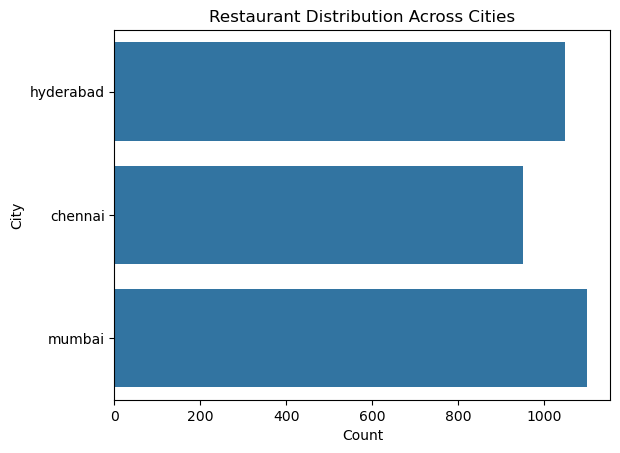

In [30]:
plt.figure()
sns.countplot(y="City", data=df)
plt.title("Restaurant Distribution Across Cities")
plt.xlabel("Count")
plt.ylabel("City")
plt.show()

### 2. Average Price per City

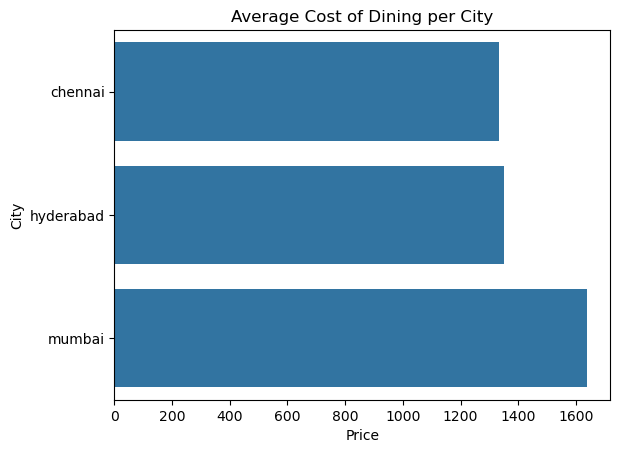

In [31]:
avg_price = df.groupby("City")["Price"].mean().sort_values()

plt.figure()
sns.barplot(x=avg_price.values, y=avg_price.index)
plt.title("Average Cost of Dining per City")
plt.xlabel("Price")
plt.ylabel("City")
plt.show()

### 3. Average Rating per City

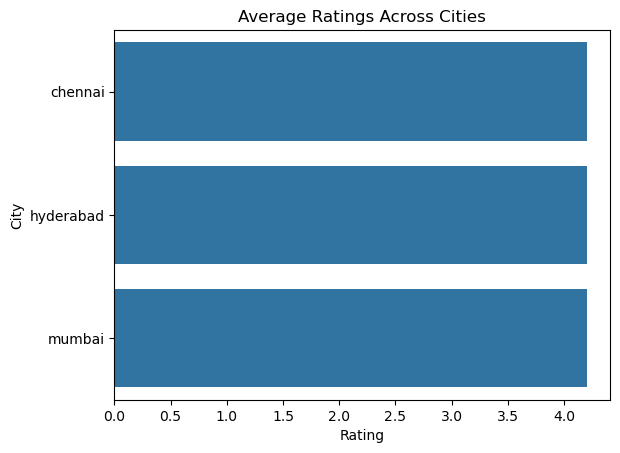

In [32]:
avg_rating = df.groupby("City")["Rating"].mean().sort_values()

plt.figure()
sns.barplot(x=avg_rating.values, y=avg_rating.index)
plt.title("Average Ratings Across Cities")
plt.xlabel("Rating")
plt.ylabel("City")
plt.show()

### 4. Price vs Rating

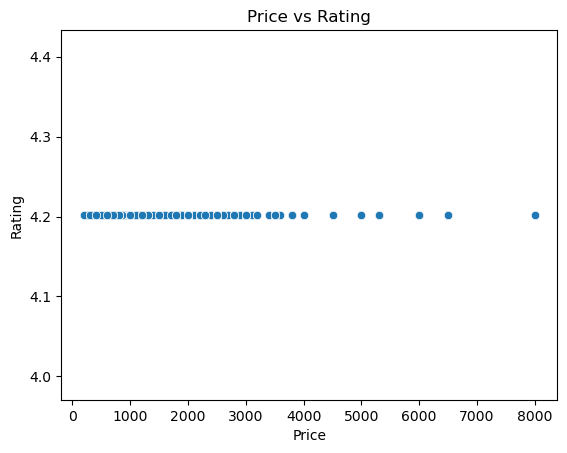

In [33]:
plt.figure()
sns.scatterplot(x="Price", y="Rating", data=df)
plt.title("Price vs Rating")
plt.xlabel("Price")
plt.ylabel("Rating")
plt.show()

### 5. Price Distribution

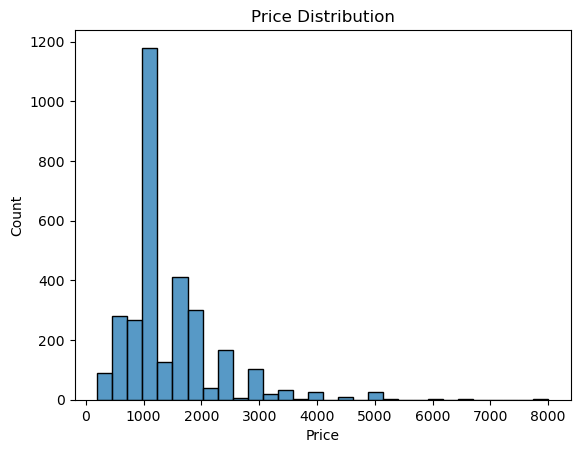

In [34]:
plt.figure()
sns.histplot(df["Price"], bins=30)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.show()

### 6. Rating Distribution

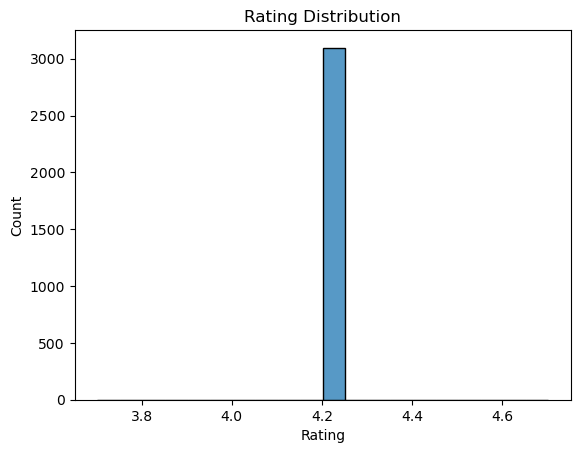

In [35]:
plt.figure()
sns.histplot(df["Rating"], bins=20)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.show()

### 7. Top Cuisines

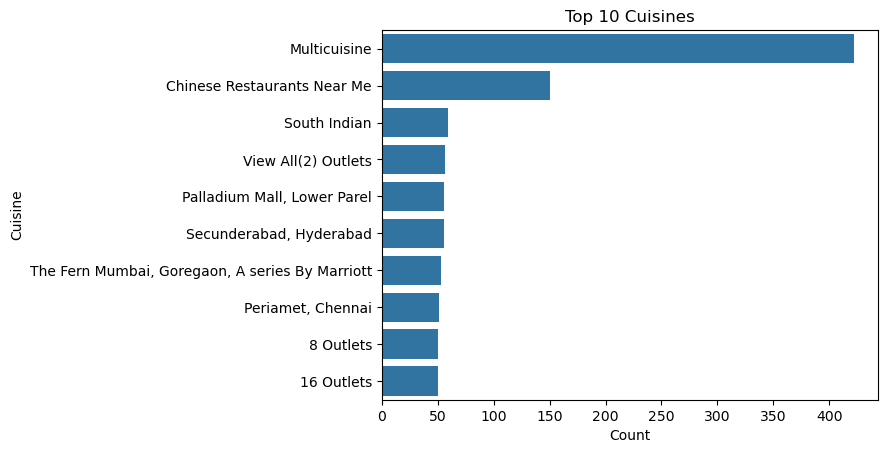

In [36]:
top_cuisine = df["Cuisine"].value_counts().head(10)

plt.figure()
sns.barplot(x=top_cuisine.values, y=top_cuisine.index)
plt.title("Top 10 Cuisines")
plt.xlabel("Count")
plt.ylabel("Cuisine")
plt.show()

### 8. Correlation Analysis: Price vs Rating

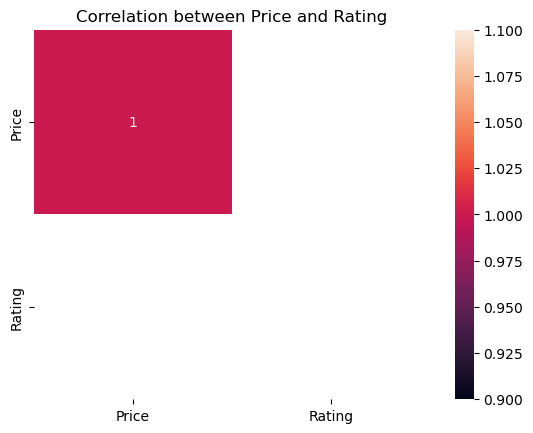

In [37]:
plt.figure()
sns.heatmap(df[["Price", "Rating"]].corr(), annot=True)
plt.title("Correlation between Price and Rating")
plt.show()

# Part 10: Insights

1. Restaurant distribution varies across cities, showing different market sizes.

2. Cities like Mumbai and Bangalore tend to have higher average prices,
   indicating premium dining markets.

3. Ratings are relatively consistent across cities,
   suggesting similar customer satisfaction levels.

4. There is no strong correlation between price and rating,
   meaning expensive restaurants are not always better rated.

5. Most restaurants fall within a mid-price range,
   indicating affordability is a key factor.

# Part 11: Conclusion

This project demonstrates an end-to-end data analysis workflow,
including data collection, cleaning, and exploratory analysis.

The analysis shows that pricing varies across cities while ratings remain stable.
It also highlights that higher pricing does not guarantee better customer experience.

Due to dynamic content loading on the website, data availability across cities 
may vary. However, the dataset remains sufficient for meaningful analysis.

Despite minor inconsistencies in the scraped data,
the dataset provides meaningful insights into restaurant trends.

In [39]:
df.to_csv("restaurant_data.csv", index=False)